In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [7]:
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

In [8]:
df = pd.read_csv(r'/Users/a/Downloads/spotify_churn_dataset.csv')

df = df.dropna()

In [9]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


/var/folders/zp/tg2cc7px5ws321s1cc32zhz40000gn/T/ipykernel_2062/475731748.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [15]:
X = df.drop('is_churned', axis=1)
y = df['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.to_csv(
    'outputs/tables/rq1_feature_importance.csv',
    index=False
)


              precision    recall  f1-score   support

           0       0.75      1.00      0.86      1200
           1       0.50      0.01      0.01       400

    accuracy                           0.75      1600
   macro avg       0.63      0.50      0.44      1600
weighted avg       0.69      0.75      0.65      1600



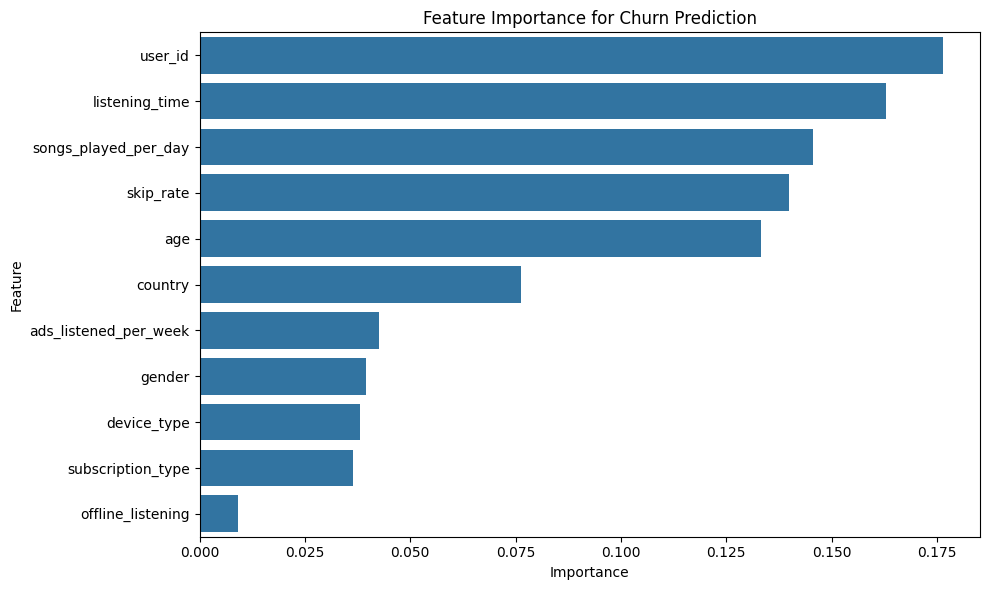

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,
            x='Importance',
            y='Feature')

plt.title('Feature Importance for Churn Prediction')
plt.tight_layout()
plt.savefig('outputs/figures/rq1_feature_importance.pdf')
plt.show()